# 🌾 Validación QA/QC de Datos GDHY (1981–2016)

### Objetivo
Evaluar la **calidad, consistencia y completitud** del dataset global de rendimientos agrícolas **GDHY** antes de aplicar técnicas de detrend o correlaciones climáticas.

---

### Etapas de Validación

1. **Integridad estructural**
   - Revisión de dimensiones, coordenadas y rango temporal (1981–2016).
   - Detección de años faltantes o duplicados.

2. **Completitud temporal y espacial**
   - Conteo de años válidos por píxel.
   - Cálculo del porcentaje de cobertura temporal y mapas de cobertura.

3. **Consistencia física**
   - Verificación de rangos de rendimiento (0–20 t/ha).
   - Detección de valores negativos o extremos (>20 t/ha).

4. **Estabilidad estadística**
   - Análisis del promedio global de rendimiento y su tendencia temporal.
   - Revisión de la desviación estándar temporal por píxel.

5. **Outliers y series constantes**
   - Identificación de píxeles con valores atípicos o sin variabilidad (std ≈ 0).

6. **Máscara de calidad (QC) preliminar**
   - Criterios: ≥30 años válidos, media >0.05 t/ha, sin outliers ni valores constantes.
   - Genera un mapa `qc_mask_prelim` (=1 si pasa los filtros).

7. **Interpolación opcional de huecos cortos**
   - Relleno de huecos ≤2 años consecutivos usando interpolación lineal.
   - Solo para píxeles que cumplen la máscara QC.

8. **Máscara QC final**
   - Validación posterior a la interpolación.
   - Crea `qc_mask_final` (=1 si la serie queda completa).

9. **Exportes**
   - Mapas de media, std, cobertura, outliers y máscaras.
   - Dataset limpio `*_QAQC.nc` con `yield_clean` y `qc_mask_final`.
   - Log `qaqc_log.json` con parámetros y métricas globales.

---

### Resultado esperado
✅ Dataset limpio, físicamente consistente, con cobertura completa y máscara QC lista para aplicar técnicas de detrend por píxel.


[LOAD] Archivos: 36 años -> 1981..2016
[INTEGRITY] dims: FrozenMappingWarningOnValuesAccess({'time': 36, 'lat': 360, 'lon': 720})
[INTEGRITY] años faltantes: []
[INTEGRITY] años duplicados: []
  [plot] -> C:\Users\paola\Tesis\02_Procesados\GDHY_QAQC\maize\global_mean_timeseries.png
  [plot] -> C:\Users\paola\Tesis\02_Procesados\GDHY_QAQC\maize\coverage_fraction.png
  [plot] -> C:\Users\paola\Tesis\02_Procesados\GDHY_QAQC\maize\coverage_hist.png
[PHYS] stats_before: {'min': 0.0, 'p01': 0.06200065955519676, 'p05': 0.25226810574531555, 'p25': 1.0427257418632507, 'p50': 2.337592840194702, 'p75': 5.110976457595825, 'p95': 11.77657318115234, 'p99': 15.625934810638423, 'max': 31.281274795532227, 'mean': 3.6949410438537598, 'std': 3.7271158695220947}
  [plot] -> C:\Users\paola\Tesis\02_Procesados\GDHY_QAQC\maize\mean_map.png
  [plot] -> C:\Users\paola\Tesis\02_Procesados\GDHY_QAQC\maize\std_map.png
[OUTLIERS] valores < 0.0: 0
[OUTLIERS] valores > 20.0: 1266
  [plot] -> C:\Users\paola\Tesis\02_

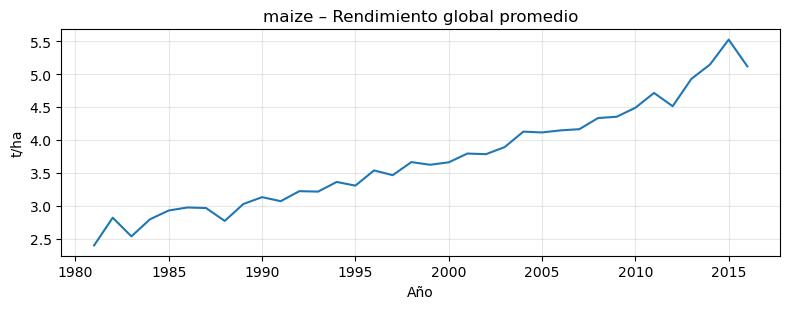

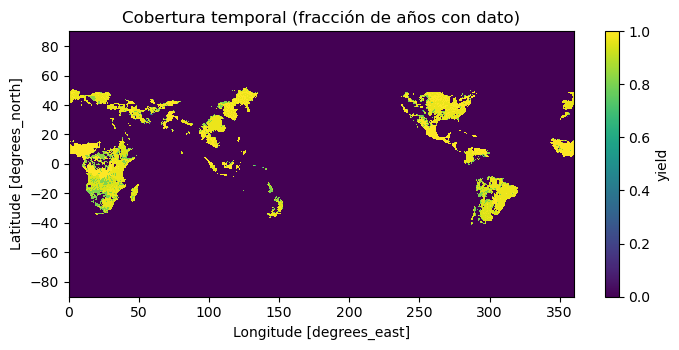

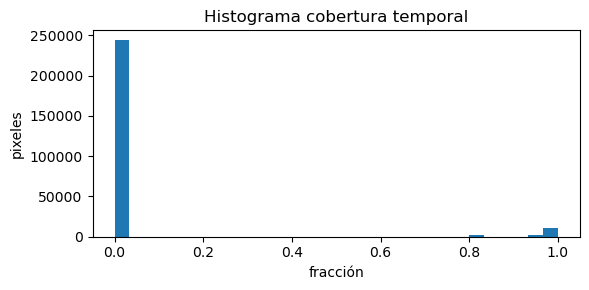

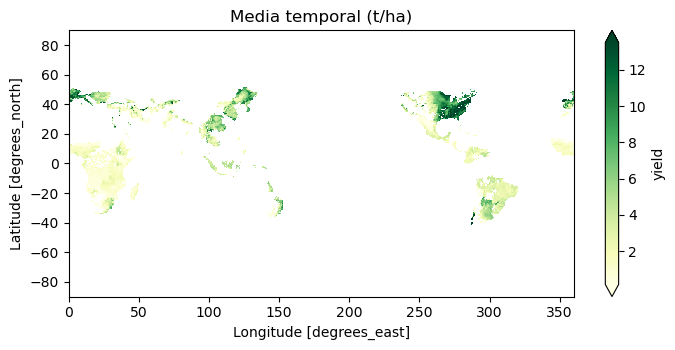

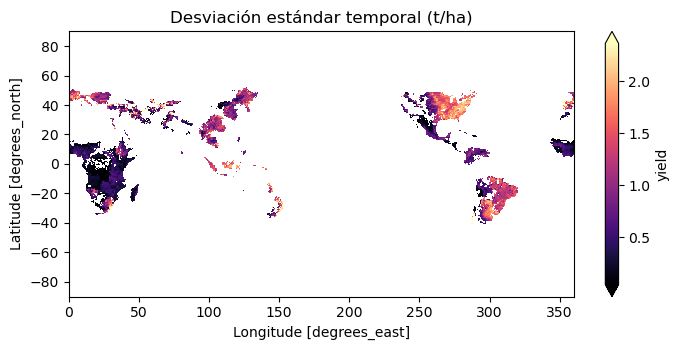

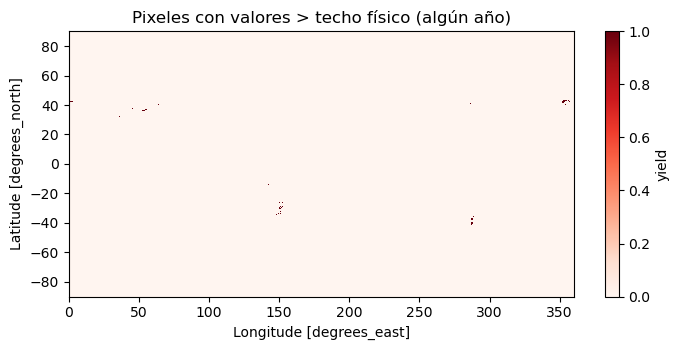

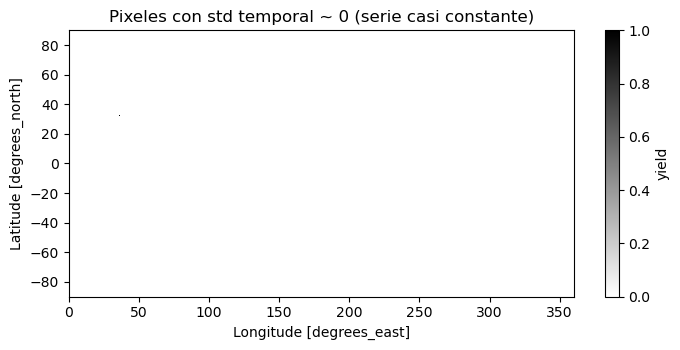

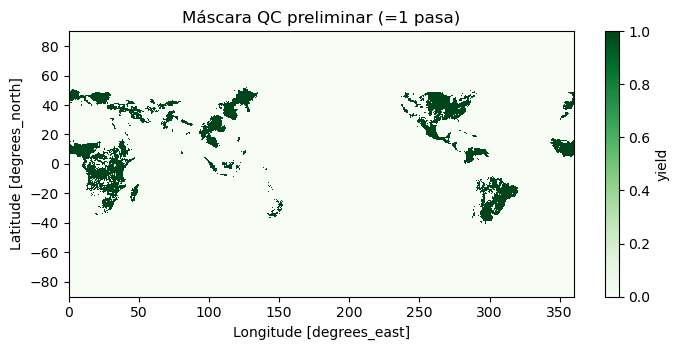

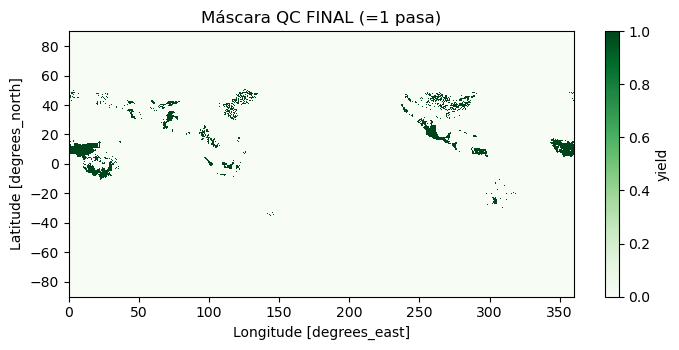

In [4]:
# =========================================================
# QA/QC INTEGRAL PARA RENDIMIENTOS GDHY (1981–2016)
# - Integridad estructural
# - Completitud temporal/espacial
# - Consistencia física (rangos)
# - Outliers / valores constantes
# - Métricas y mapas por etapa
# - Máscara de calidad final (qc_mask)
# =========================================================

import os, glob, json
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt

# ------------------ CONFIG ------------------
CROP_NAME   = "maize"  # maize | wheat | rice
ORIG_DIR    = rf"C:\Users\paola\Tesis\01_Data\CEREALS\gdhy_v1.2_v1.3_20190128\{CROP_NAME}"
OUT_DIR     = rf"C:\Users\paola\Tesis\02_Procesados\GDHY_QAQC\{CROP_NAME}"
os.makedirs(OUT_DIR, exist_ok=True)

EXPECTED_YEARS = list(range(1981, 2017))  # 36 años

# Umbrales QA/QC
MIN_VALID_YEARS   = 30      # exigir >=30 años válidos
MIN_MEAN_YIELD    = 0.05    # t/ha
MAX_REASONABLE_Y  = 20.0    # t/ha, techo físico maíz global
MIN_REASONABLE_Y  = 0.0     # t/ha
CONST_STD_EPS     = 1e-6    # std ~0 => serie constante
DO_INTERPOLATE_SHORT_GAPS = True
MAX_GAP_YEARS     = 2       # interpola huecos consecutivos <= 2 años

# Chunks recomendados (time en un solo bloque)
CH_TIME = -1
CH_LAT  = 180
CH_LON  = 360

# ------------------ UTILIDADES ------------------
def save_fig(path):
    plt.savefig(path, dpi=140, bbox_inches="tight")
    print("  [plot] ->", path)

def describe_series(arr):
    q = np.nanpercentile(arr, [0,1,5,25,50,75,95,99,100])
    return dict(min=float(q[0]), p01=float(q[1]), p05=float(q[2]), p25=float(q[3]),
                p50=float(q[4]), p75=float(q[5]), p95=float(q[6]),
                p99=float(q[7]), max=float(q[8]), mean=float(np.nanmean(arr)),
                std=float(np.nanstd(arr, ddof=1)))

# ------------------ 1) CARGA ------------------
files = sorted(glob.glob(os.path.join(ORIG_DIR, "yield_*.nc4")))
assert len(files) > 0, f"No encontré archivos yield_*.nc4 en {ORIG_DIR}"
years = [int(os.path.basename(f).split('_')[-1].split('.')[0]) for f in files]
print(f"[LOAD] Archivos: {len(files)} años -> {years[0]}..{years[-1]}")

ds = xr.open_mfdataset(
    files,
    combine="nested",
    concat_dim="time",
    engine="netcdf4",
    parallel=True,
    chunks={"time": CH_TIME, "lat": CH_LAT, "lon": CH_LON}  # time en un solo chunk
).rename({"var": "yield"})

# aseguramos chunking uniforme
ds = ds.chunk({"time": CH_TIME, "lat": CH_LAT, "lon": CH_LON})
y  = ds["yield"].chunk({"time": CH_TIME, "lat": CH_LAT, "lon": CH_LON})

# coordenada de tiempo explícita
ds = ds.assign_coords(time=("time", years))
y  = y.assign_coords(time=("time", years))

# ------------------ 2) INTEGRIDAD ------------------
print("[INTEGRITY] dims:", ds.dims)
missing_years = sorted(set(EXPECTED_YEARS) - set(years))
dup_years     = [yr for yr in years if years.count(yr) > 1]
print("[INTEGRITY] años faltantes:", missing_years)
print("[INTEGRITY] años duplicados:", sorted(set(dup_years)))

# Serie global promedio
global_mean = y.mean(dim=["lat","lon"], skipna=True)
plt.figure(figsize=(8,3.2))
global_mean.plot()
plt.title(f"{CROP_NAME} – Rendimiento global promedio")
plt.xlabel("Año"); plt.ylabel("t/ha"); plt.grid(True, alpha=0.3); plt.tight_layout()
save_fig(os.path.join(OUT_DIR, "global_mean_timeseries.png"))
pd.DataFrame({"year": years, "global_mean_yield": global_mean.values}).to_csv(
    os.path.join(OUT_DIR, "global_mean_timeseries.csv"), index=False
)

# ------------------ 3) COMPLETITUD ------------------
valid_count = np.isfinite(y).sum(dim="time")
total_years = y.sizes["time"]
coverage    = (valid_count / total_years).astype("float32")

plt.figure(figsize=(7.2,3.6))
coverage.plot(cmap="viridis", vmin=0, vmax=1)
plt.title("Cobertura temporal (fracción de años con dato)")
plt.tight_layout()
save_fig(os.path.join(OUT_DIR, "coverage_fraction.png"))

plt.figure(figsize=(6,3))
plt.hist(coverage.values.ravel(), bins=30)
plt.title("Histograma cobertura temporal"); plt.xlabel("fracción"); plt.ylabel("pixeles")
plt.tight_layout(); save_fig(os.path.join(OUT_DIR, "coverage_hist.png"))

# ------------------ 4) CONSISTENCIA FÍSICA ------------------
stats_before = describe_series(y.values)
with open(os.path.join(OUT_DIR, "stats_before.json"), "w") as f:
    json.dump(stats_before, f, indent=2)
print("[PHYS] stats_before:", stats_before)

plt.figure(figsize=(7.2,3.6))
y.mean(dim="time", skipna=True).plot(cmap="YlGn", robust=True)
plt.title("Media temporal (t/ha)"); plt.tight_layout()
save_fig(os.path.join(OUT_DIR, "mean_map.png"))

plt.figure(figsize=(7.2,3.6))
y.std(dim="time", skipna=True).plot(cmap="magma", robust=True)
plt.title("Desviación estándar temporal (t/ha)"); plt.tight_layout()
save_fig(os.path.join(OUT_DIR, "std_map.png"))

# ------------------ 5) OUTLIERS Y VALORES CONSTANTES ------------------
phys_low  = y < MIN_REASONABLE_Y
phys_high = y > MAX_REASONABLE_Y

std_map = y.std(dim="time", skipna=True)
const_like = std_map <= CONST_STD_EPS

# resumen outliers
n_phys_low  = int(np.nansum(phys_low))
n_phys_high = int(np.nansum(phys_high))
print(f"[OUTLIERS] valores < {MIN_REASONABLE_Y}: {n_phys_low}")
print(f"[OUTLIERS] valores > {MAX_REASONABLE_Y}: {n_phys_high}")

plt.figure(figsize=(7.2,3.6))
phys_high.any(dim="time").astype("uint8").plot(cmap="Reds")
plt.title("Pixeles con valores > techo físico (algún año)"); plt.tight_layout()
save_fig(os.path.join(OUT_DIR, "phys_high_mask.png"))

plt.figure(figsize=(7.2,3.6))
const_like.astype("uint8").plot(cmap="gray_r")
plt.title("Pixeles con std temporal ~ 0 (serie casi constante)"); plt.tight_layout()
save_fig(os.path.join(OUT_DIR, "constant_series_mask.png"))

# ------------------ 6) MÁSCARA DE CALIDAD PRELIMINAR ------------------
mean_yield = y.mean(dim="time", skipna=True)

qc_mask = (coverage >= (MIN_VALID_YEARS/total_years)) & \
          (mean_yield > MIN_MEAN_YIELD) & \
          (~const_like) & \
          (~phys_high.any(dim="time")) & \
          (~phys_low.any(dim="time"))

# alinear chunks de la máscara con y
qc_mask = qc_mask.chunk({"lat": CH_LAT, "lon": CH_LON})

plt.figure(figsize=(7.2,3.6))
qc_mask.astype("uint8").plot(cmap="Greens")
plt.title("Máscara QC preliminar (=1 pasa)"); plt.tight_layout()
save_fig(os.path.join(OUT_DIR, "qc_mask_prelim.png"))

summary_ds = xr.Dataset({
    "coverage": coverage,
    "valid_years": valid_count.astype("int16"),
    "mean_yield": mean_yield.astype("float32"),
    "std_yield": std_map.astype("float32"),
    "qc_mask_prelim": qc_mask.astype("uint8")
})
summary_ds.to_netcdf(os.path.join(OUT_DIR, "summary_qaqc_prelim.nc"))

# ------------------ 7) INTERPOLACIÓN DE HUECOS CORTOS ------------------
y_interp = y.copy()
interp_report = {"enabled": bool(DO_INTERPOLATE_SHORT_GAPS),
                 "used_fallback": False,
                 "interpolated_pixels": 0}

if DO_INTERPOLATE_SHORT_GAPS:
    try:
        # IMPORTANTÍSIMO: where cambia chunking → re-chunk de nuevo
        y_for_interp = y.where(qc_mask).chunk({"time": CH_TIME, "lat": CH_LAT, "lon": CH_LON})
        # algunos xarray requieren también rechunk explícito de 'y'
        y_for_interp = y_for_interp.chunk({"time": CH_TIME})
        # interpolación (si tu versión soporta max_gap)
        y_interp = y_for_interp.interpolate_na(
            dim="time", method="linear", max_gap=MAX_GAP_YEARS
        )
        # reporte simple
        valid_after = np.isfinite(y_interp).sum(dim="time")
        full_series = valid_after == total_years
        interp_report["interpolated_pixels"] = int(full_series.sum())
        plt.figure(figsize=(7.2,3.6))
        full_series.astype("uint8").plot(cmap="Blues")
        plt.title("Serie completa tras interpolación (<=2 años de gap)")
        plt.tight_layout()
        save_fig(os.path.join(OUT_DIR, "full_series_after_interp.png"))
    except Exception as e:
        print("[INTERP] Fallback por error en interpolate_na:", repr(e))
        # Fallback seguro: no interpolar, solo aplicar máscara
        y_interp = y.where(qc_mask)
        interp_report["used_fallback"] = True

else:
    y_interp = y.where(qc_mask)

# aseguramos chunks antes de siguientes operaciones
y_interp = y_interp.chunk({"time": CH_TIME, "lat": CH_LAT, "lon": CH_LON})

# ------------------ 8) MÁSCARA QC FINAL ------------------
valid_count_after = np.isfinite(y_interp).sum(dim="time")
qc_mask_final = qc_mask & (valid_count_after == total_years)

plt.figure(figsize=(7.2,3.6))
qc_mask_final.astype("uint8").plot(cmap="Greens")
plt.title("Máscara QC FINAL (=1 pasa)"); plt.tight_layout()
save_fig(os.path.join(OUT_DIR, "qc_mask_final.png"))

# ------------------ 9) EXPORTES Y LOG ------------------
out_ds = xr.Dataset({
    "yield_raw": y,  # comenta si quieres ahorrar disco
    "yield_clean": y_interp.where(qc_mask_final),
    "valid_years_before": valid_count.astype("int16"),
    "valid_years_after": valid_count_after.astype("int16"),
    "coverage": coverage.astype("float32"),
    "mean_yield": mean_yield.astype("float32"),
    "std_yield": std_map.astype("float32"),
    "qc_mask_final": qc_mask_final.astype("uint8")
}, coords=y.coords)

nc_out = os.path.join(OUT_DIR, f"{CROP_NAME}_GDHY_1981_2016_QAQC.nc")
out_ds.to_netcdf(nc_out)
print("[SAVE] NetCDF QAQC ->", nc_out)

log = {
    "crop": CROP_NAME,
    "years_found": [int(min(years)), int(max(years))],
    "missing_years": missing_years,
    "dup_years": sorted(set(dup_years)),
    "total_pixels": int(y.sizes["lat"] * y.sizes["lon"]),
    "stats_before": describe_series(y.values),
    "thresholds": dict(
        MIN_VALID_YEARS=MIN_VALID_YEARS,
        MIN_MEAN_YIELD=MIN_MEAN_YIELD,
        MAX_REASONABLE_Y=MAX_REASONABLE_Y,
        MIN_REASONABLE_Y=MIN_REASONABLE_Y,
        CONST_STD_EPS=CONST_STD_EPS,
        DO_INTERPOLATE_SHORT_GAPS=DO_INTERPOLATE_SHORT_GAPS,
        MAX_GAP_YEARS=MAX_GAP_YEARS
    ),
    "interpolation": interp_report
}
with open(os.path.join(OUT_DIR, "qaqc_log.json"), "w") as f:
    json.dump(log, f, indent=2)
print("[SAVE] Log ->", os.path.join(OUT_DIR, "qaqc_log.json"))

print("\n=== QA/QC LISTO ===")
print("Revisa OUT_DIR:", OUT_DIR)
print("- global_mean_timeseries.(png/csv)")
print("- coverage_fraction.png, coverage_hist.png")
print("- mean_map.png, std_map.png")
print("- phys_high_mask.png, constant_series_mask.png")
print("- qc_mask_prelim.png, full_series_after_interp.png (si aplica), qc_mask_final.png")
print("- summary_qaqc_prelim.nc, *_QAQC.nc, qaqc_log.json")


Dataset limpio cargado: (36, 360, 720)
✅ Guardado: C:\Users\paola\Tesis\02_Procesados\GDHY_detrend\GDHY_maize_1981_2016_DETREND_clean.nc


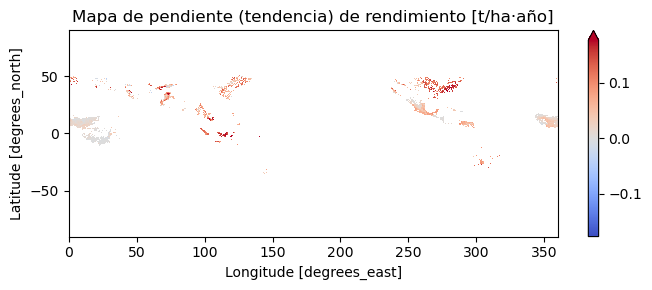

In [5]:
# =========================================================
# DETREND LINEAL PIXEL-WISE sobre datos limpios QA/QC
# =========================================================
import os
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

# === RUTAS ===
QAQC_FILE = r"C:\Users\paola\Tesis\02_Procesados\GDHY_QAQC\maize\maize_GDHY_1981_2016_QAQC.nc"
OUT_DIR   = r"C:\Users\paola\Tesis\02_Procesados\GDHY_detrend"
os.makedirs(OUT_DIR, exist_ok=True)
OUT_FILE  = os.path.join(OUT_DIR, "GDHY_maize_1981_2016_DETREND_clean.nc")

# === CARGA ===
ds = xr.open_dataset(QAQC_FILE)
y  = ds["yield_clean"].where(ds["qc_mask_final"] == 1)
time_dim = "time"

print(f"Dataset limpio cargado: {y.shape}")

# === FUNCIÓN DETREND ===
def detrend_linear_pixelwise(da, time_dim="time"):
    """Elimina tendencia lineal por píxel."""
    t  = da[time_dim].astype("float32")
    t0 = t - t.mean(dim=time_dim)
    y0 = da - da.mean(dim=time_dim)
    var_t = (t0**2).mean(dim=time_dim)
    cov_ty = (t0 * y0).mean(dim=time_dim)
    b = cov_ty / var_t
    a = da.mean(dim=time_dim) - b * t.mean(dim=time_dim)
    trend = a + b * t
    anom  = da - trend
    for v in (anom, a, b): v.attrs = {}
    return anom, a, b

# === DETREND ===
anom, a_map, b_map = detrend_linear_pixelwise(y, time_dim)

# === GUARDAR ===
out = xr.Dataset({
    "yield_detrended": anom.astype("float32"),
    "yield_trend_intercept": a_map.astype("float32"),
    "yield_trend_slope": b_map.astype("float32")
}, coords=y.coords, attrs={
    "note": "Pixel-wise linear detrend aplicado sobre yield_clean (QAQC)"
})

out.to_netcdf(OUT_FILE)
print("✅ Guardado:", OUT_FILE)

# === VERIFICACIÓN RÁPIDA ===
plt.figure(figsize=(7,3))
b_map.plot(cmap="coolwarm", robust=True)
plt.title("Mapa de pendiente (tendencia) de rendimiento [t/ha·año]")
plt.tight_layout()
plt.show()
